In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
shops = pd.read_csv('../../raw_data/shops.csv')
items = pd.read_csv('../../raw_data/items.csv')
item_categories = pd.read_csv('../../raw_data/item_categories.csv')
sales_train = pd.read_csv('../../raw_data/sales_train.csv')

In [3]:
shops.info()

<class 'pandas.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   shop_name  60 non-null     str  
 1   shop_id    60 non-null     int64
dtypes: int64(1), str(1)
memory usage: 1.1 KB


In [4]:
item_categories.info()

<class 'pandas.DataFrame'>
RangeIndex: 84 entries, 0 to 83
Data columns (total 2 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   item_category_name  84 non-null     str  
 1   item_category_id    84 non-null     int64
dtypes: int64(1), str(1)
memory usage: 1.4 KB


In [5]:
items.info()

<class 'pandas.DataFrame'>
RangeIndex: 22170 entries, 0 to 22169
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   item_name         22170 non-null  str  
 1   item_id           22170 non-null  int64
 2   item_category_id  22170 non-null  int64
dtypes: int64(2), str(1)
memory usage: 519.7 KB


In [6]:
items['item_name'].nunique()

22170

In [7]:
items['item_category_id'].nunique()

84

In [8]:
sales_train.info(show_counts=True)

<class 'pandas.DataFrame'>
RangeIndex: 2935849 entries, 0 to 2935848
Data columns (total 6 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   date            2935849 non-null  str    
 1   date_block_num  2935849 non-null  int64  
 2   shop_id         2935849 non-null  int64  
 3   item_id         2935849 non-null  int64  
 4   item_price      2935849 non-null  float64
 5   item_cnt_day    2935849 non-null  float64
dtypes: float64(2), int64(3), str(1)
memory usage: 134.4 MB


In [9]:
sales_train.sample(5)

,date,date_block_num,shop_id,item_id,item_price,item_cnt_day
1481805,04.03.2014,14,54,14229,99.0,2.0
2397237,06.01.2015,24,51,18431,167.0,1.0
2382964,16.01.2015,24,57,10383,399.0,1.0
219492,10.02.2013,1,28,3676,1599.0,1.0
1421426,23.02.2014,13,52,19193,149.0,1.0


<Axes: xlabel='date_block_num', ylabel='item_cnt_day'>

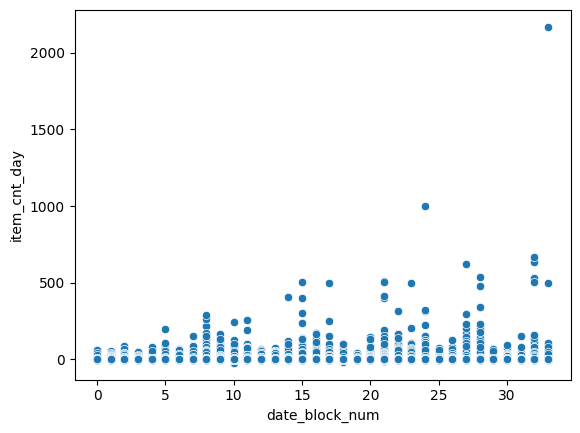

In [56]:
sns.scatterplot(data=sales_train, x='date_block_num', y='item_cnt_day')

<Axes: xlabel='date_block_num', ylabel='item_price'>

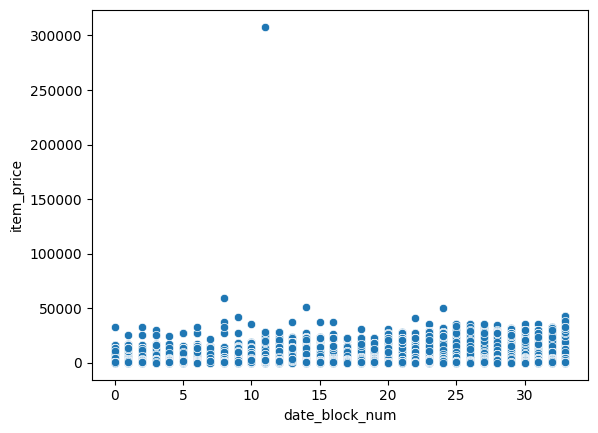

In [57]:
sns.scatterplot(data=sales_train, x='date_block_num', y='item_price')

In [58]:
sales_train.sample(5)

,date,date_block_num,shop_id,item_id,item_price,item_cnt_day
2354269,23.01.2015,24,24,9914,499.0,1.0
2415065,23.02.2015,25,45,15286,1499.0,1.0
2326217,05.01.2015,24,15,8702,399.0,1.0
2286223,20.12.2014,23,6,15916,1799.0,1.0
2377948,25.01.2015,24,37,4806,99.0,1.0


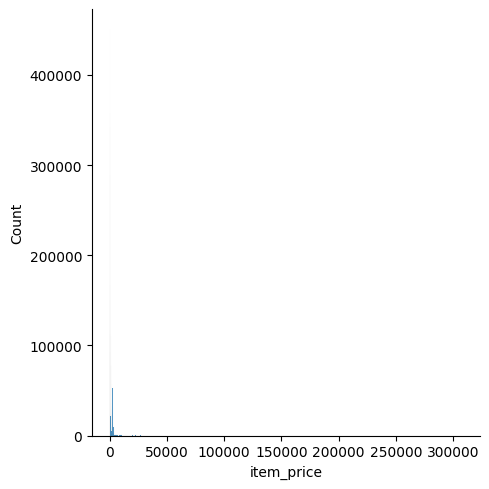

In [62]:
sns.displot(data=sales_train, x='item_price')

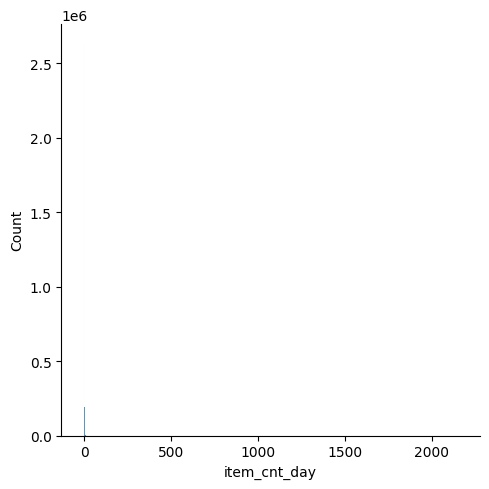

In [10]:
sns.displot(data=sales_train, x='item_cnt_day')

In [66]:
sales_train[sales_train['item_price'] > 100000]

,date,date_block_num,shop_id,item_id,item_price,item_cnt_day
1163158,13.12.2013,11,12,6066,307980.0,1.0


In [67]:
sales_train[sales_train['item_cnt_day'] > 500]

,date,date_block_num,shop_id,item_id,item_price,item_cnt_day
1573253,22.04.2014,15,27,8057,1200.000000,502.0
1708207,28.06.2014,17,25,20949,5.000000,501.0
2048518,02.10.2014,21,12,9242,1500.000000,512.0
2067669,09.10.2014,21,55,19437,899.000000,508.0
2326930,15.01.2015,24,12,20949,4.000000,1000.0
2608040,14.04.2015,27,12,3731,1904.548077,624.0
2626181,19.05.2015,28,12,11373,155.192950,539.0
2851073,29.09.2015,32,55,9249,1500.000000,533.0
2851091,30.09.2015,32,55,9249,1702.825746,637.0
2864235,30.09.2015,32,12,9248,1692.526158,669.0


## Сравним до и после чистки (Удалили экстремальные значения, дубликаты, отрицательные в цене)

In [57]:
shops_clean = pd.read_csv('../clean_data/shops.csv')
items_clean = pd.read_csv('../clean_data/items.csv')
item_categories_clean = pd.read_csv('../clean_data/item_categories.csv')
sales_train_clean = pd.read_csv('../clean_data/sales_train.csv')

<Axes: ylabel='item_cnt_day'>

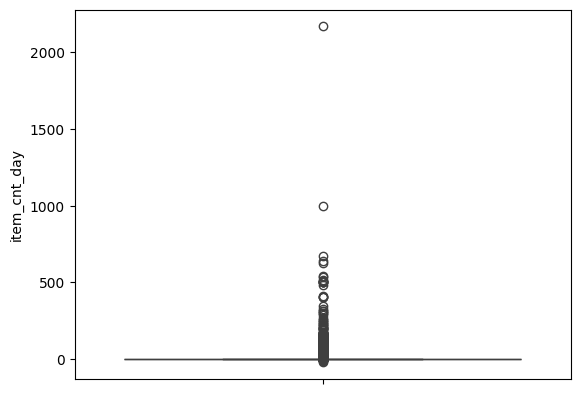

In [58]:
sns.boxplot(data=sales_train, y='item_cnt_day')

<Axes: ylabel='item_cnt_day'>

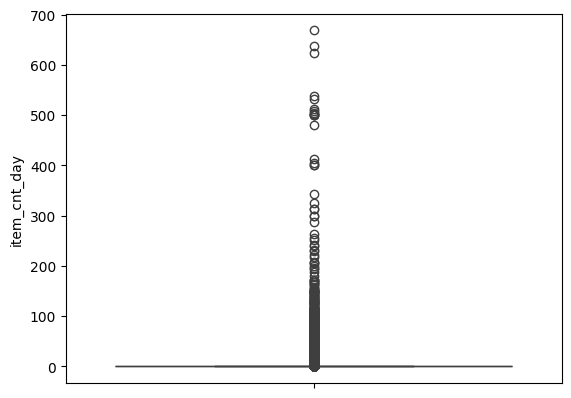

In [59]:
sns.boxplot(data=sales_train_clean, y='item_cnt_day')

<Axes: ylabel='item_price'>

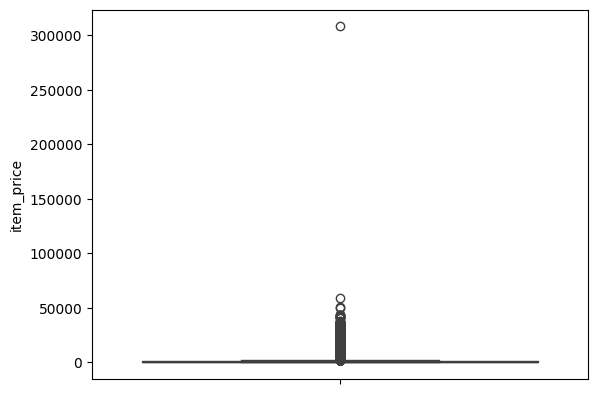

In [60]:
sns.boxplot(data=sales_train, y='item_price')

<Axes: ylabel='item_price'>

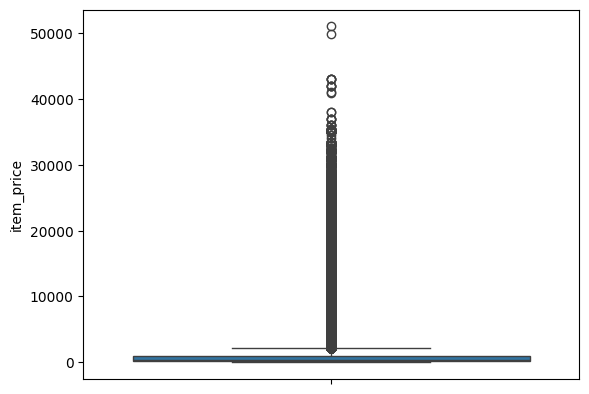

In [61]:
sns.boxplot(data=sales_train_clean, y='item_price')

<Axes: xlabel='date_block_num', ylabel='item_price'>

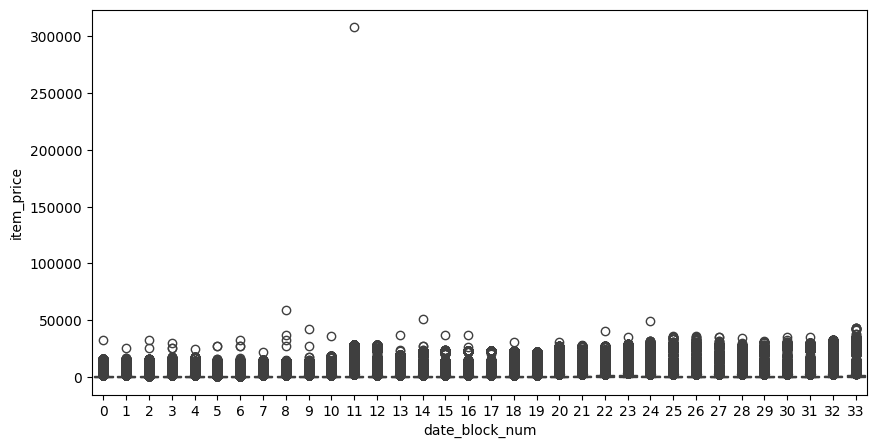

In [62]:
plt.figure(figsize=(10,5))
sns.boxplot(data=sales_train, y='item_price', x='date_block_num')

<Axes: xlabel='date_block_num', ylabel='item_price'>

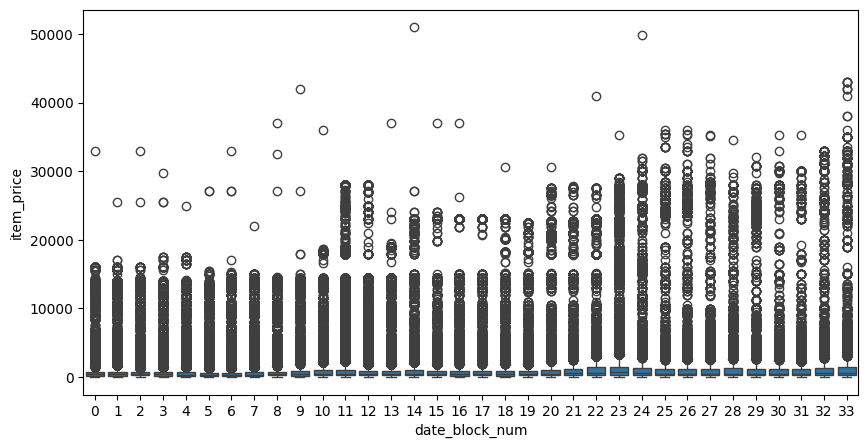

In [63]:
plt.figure(figsize=(10,5))
sns.boxplot(data=sales_train_clean, y='item_price', x='date_block_num')

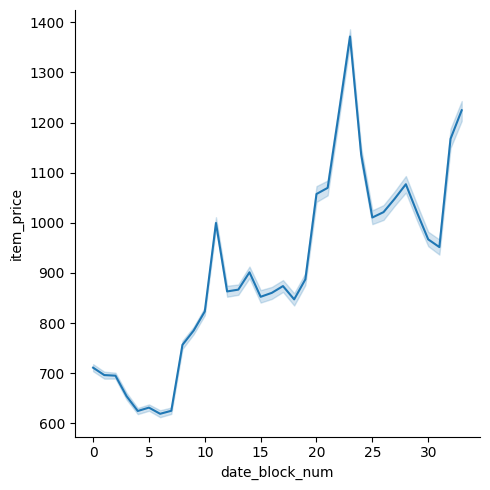

In [64]:
sns.relplot(
    data=sales_train,
    x="date_block_num",
    y="item_price",
    kind='line'
)

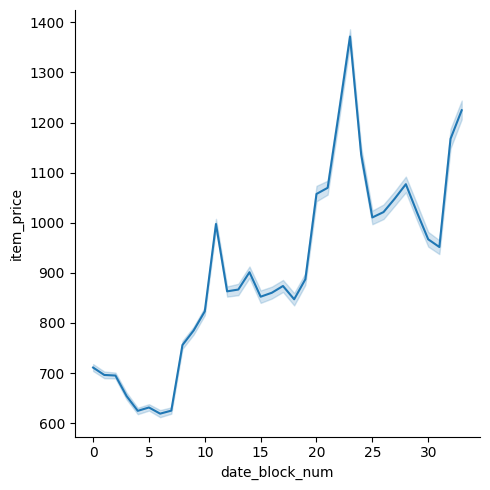

In [65]:
sns.relplot(
    data=sales_train_clean,
    x="date_block_num",
    y="item_price",
    kind='line'
)

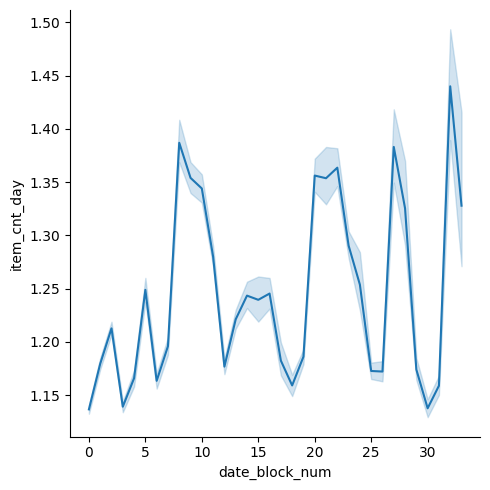

In [66]:

sns.relplot(
    data=sales_train,
    x="date_block_num",
    y="item_cnt_day",
    kind='line'
)


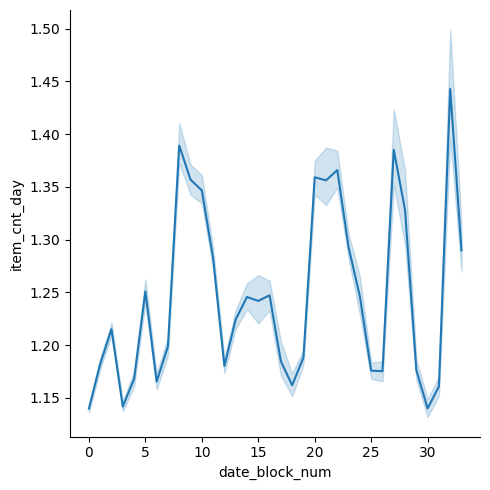

In [67]:

sns.relplot(
    data=sales_train_clean,
    x="date_block_num",
    y="item_cnt_day",
    kind='line'
)
